## Lab Session 3

## Basics working with data

In this notebook we will practice the following "data science" steps:
1. Handeling of missing values.
2. Visualising the data.
3. Learning insights from you data.

We will not give a complete course in Python, but will expect you to do some self-study. 
The idea is that you will fill in the answers in this notebook, save it, and upload to to Black Board before the deadline.

We will use the same data as in the first Lab Session, namely the Titanic data set. 
To start we will load some libraries again. This time, we will also load the "seaborn" library, which is used for creating plots.

In [1]:
import pandas as pd #importing the pandas library
import seaborn as sns #importing seaborn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Note "%matplotlib inline". This line tells the notebook to put the plot inside the notebook. This is not used in Python scripts which are executed like "normal programs".

<div class="alert alert-block alert-warning">

## Task 1: Seaborn

To illustrate how seaborn plotting works run the following example. Seaborn accesses the columns of a pandas dataframe directly. You only have to specifiy the dataframe and the name of the columns for the plotting axes.

</div>

<AxesSubplot:xlabel='index', ylabel='number'>

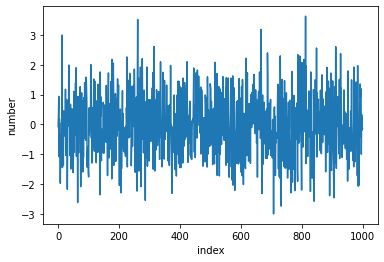

In [2]:
#Generate a random vector sampling from a normal distribution with mean=0, sig=1
#and convert in into a pandas dataframe object
#we call reset_index() on the new dataframe. This adds a new column to our dataframe, 
#which can then be accessed by seaborn to plot the data
df_random = pd.DataFrame(data=np.random.normal(size=1000),columns = ["number"]).reset_index()

#We polot the data with seaborn, specifing x and y axis and the datasource (df_random)
sns.lineplot(x="index",y="number",data=df_random)

<div class="alert alert-block alert-warning">

## Task 2: Loading the data

2.1. Load the titanic dataset ("titanic.csv") contained in this exercise using pandas functions 
into the variable <i>df_titanic</i>.

2.2. We know from the last exercise that the dataset contains missing values. Use the isnull() and sum() method of <i>df_titanic</i> to show which columns have the most missing values.
</div>


In [3]:
#Task 2.1
df_titanic = pd.read_csv('titanic.csv')

#Task 2.2
null_values = df_titanic.isnull().sum()
dict(sorted(null_values.items(), key=lambda item: item[1], reverse=True))

{'Cabin': 1014,
 'Survived': 418,
 'Age': 263,
 'Embarked': 2,
 'Fare': 1,
 'Unnamed: 0': 0,
 'Name': 0,
 'Parch': 0,
 'PassengerId': 0,
 'Pclass': 0,
 'Sex': 0,
 'SibSp': 0,
 'Ticket': 0}

<div class="alert alert-block alert-warning">

## Task 3: Imputing missing values

Three columns have missing values the most: "Age", "Cabin", and "Survived". 
Cabin misses approx. 80% of its values. Not the right candidate for simple imputation approaches.
We focus on the <strong>Age</strong> column, where about 20% are missing.

3.1. Use the <strong>fillna()</strong> method and only impute the Age column with the mean age value(see <strong>mean()</strong> method). Save the result in a new column called "Age_imp_mean".

3.2. Use the method parameter <b>method="ffill"</b> of the <b>fillna()</b> method to fill missing values by their proceding value. Save the result in a new collumn called "Age_imp_ffill".

3.3 Plot histogramms of both columns using seaborn and the <strong>distplot()</strong> function, with parameters <b>hist=True</b>, <b>kde=False</b> and <b>bins=40</b>. Also plot the standard Age column for comparision (use the dropna() to avoid error generation). Put everything into one plot.

3.4 Plot boxplots of both columns. The buildin method of the data frame <i>df_titanic</i> can be used for this. Here we want to use seaborn's boxplot function with the <strong>data=</strong> parameter.

3.5 Explain what the different parts of the boxplot are:
* Horizontal line whitin the colored area
* Width of the colored area
* With of the Area between the two horizontal lines below and above the colored area ("whiskers")
* Dots or points above and below the wiskers.

3.6 Explain what effect each imputation strategy had:
* using the histogramm - When we analyse the survival of patients with a specific age, lets say the ages close to the mean. Can we trust that the mean survial rate is accurate for that age bracket? Why or Why not?  
* using the boxplot - When we want to find outliers in regards to age, what method would yield more passengers? Why is that the case? (hint: How is an outlier defined in (seaborn) box-plots?).
</div>


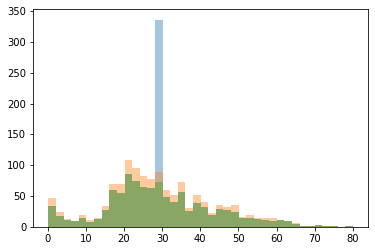

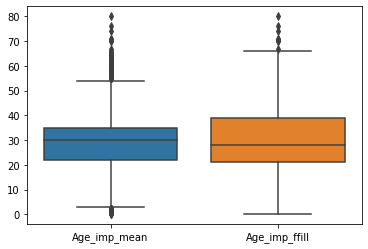

"\n--> No, We can't trust mean survival rate of age bracket. Because survival depends on many other parameters and justifying\nwith only age may leads to inaccurate results.\n--> When we fill na values with the mean value, then more passangers will be yield in outlier.Because median will not be \nin the middle of the box, and instead off to the side. You may also find an imbalance in the whisker lengths, where one \nside is short with no outliers, and the other has a long tail with many more outliers. \n"

In [4]:
import warnings
warnings.filterwarnings("ignore")

#Task 3.1
#Your code
df_titanic['Age_imp_mean'] = df_titanic['Age'].fillna(df_titanic['Age'].mean())

#Task 3.2
#Your code
df_titanic['Age_imp_ffill'] = df_titanic['Age'].fillna(method='ffill')

#Task 3.3
#Your code
plt.figure(1)
sns.distplot(df_titanic[['Age_imp_mean']], hist=True, kde=False, bins=40)
sns.distplot(df_titanic[['Age_imp_ffill']], hist=True, kde=False, bins=40)
sns.distplot(df_titanic[['Age']].dropna(), hist=True, kde=False, bins=40)
plt.show()




#Task 3.4
#Your code
plt.figure(2)
sns.boxplot(data = df_titanic[['Age_imp_mean', 'Age_imp_ffill']])
plt.show()



#Task 3.5
"""
--> Horizontal line called the Box limits. Box limits indicate the range of the central 50% of the data, with a central 
line marking the median value.
--> Box width can be used as an indicator of how many data points fall into each group\n
--> Area between below and above the colored area 25% of the data.
--> Dots placed past the line edges to indicate outliers.
"""



#Task 3.6
"""
--> No, We can't trust mean survival rate of age bracket. Because survival depends on many other parameters and justifying
with only age may leads to inaccurate results.
--> When we fill na values with the mean value, then more passangers will be yield in outlier.Because median will not be 
in the middle of the box, and instead off to the side. You may also find an imbalance in the whisker lengths, where one 
side is short with no outliers, and the other has a long tail with many more outliers. 
"""

<div class="alert alert-block alert-warning">

## Task 4

(from https://www.kaggle.com/c/titanic) The sinking of the RMS Titanic is one of the most infamous shipwrecks in history.  On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships. One of the reasons that the shipwreck led to such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others... let's see if we can figure out which ones.


First lets explore the data a bit further:
* 4.1 Use the <strong>catplot()</strong> function in pandas to make a scatterplot of "Fare" vs. "Age", colored by "Survived" (hue parameter) and split by "Sex"(col parameter). Is Age correlated with Fare? Do passengers who pay more have a better chance of survival? Is that always true?

* 4.2 Plot "Pclass" vs. "Fare" colored by Sex using a boxplot. Anything unusual besides higher fares for higher classes?

* 4.3 How is the survival rate of passengers(colored by "Sex") in the different classes ("Pclass")? Make a barplot.

</div>

<Figure size 432x288 with 0 Axes>

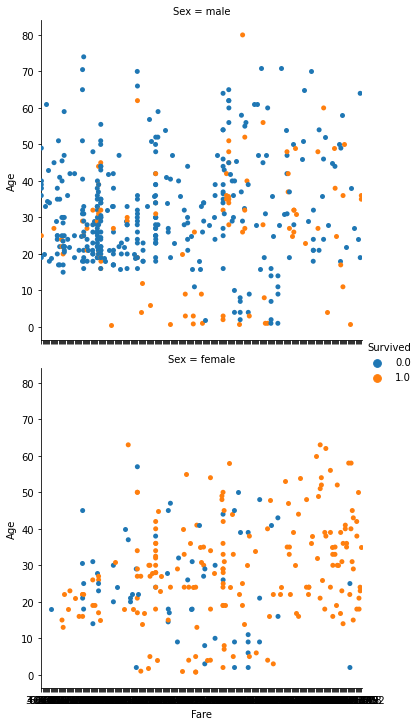

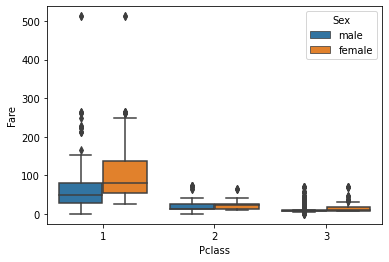

<Figure size 432x288 with 0 Axes>

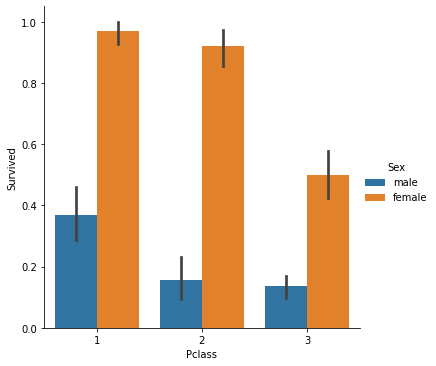

'\n--> Survival rate of female is higher then male and survival rate is increased in higher class.\n'

In [5]:
#Task 4.1
plt.figure(3)
#Your code
sns.catplot(x='Fare', y='Age', hue ='Survived', row='Sex', data=df_titanic)
plt.show()


"""
--> Age is not correlated fare. 
--> Yes, passengers who pay more have better chance of survival. 
--> No, it is not always true.
"""



#Task 4.2
plt.figure(5)
#Your code
sns.boxplot(x='Pclass', y='Fare', hue='Sex', data = df_titanic)
plt.show()


"""
--> For higher class, female paid more fare than male.
"""



#Task 4.3
plt.figure(6)
#Your code
sns.catplot(x='Pclass', y= 'Survived', hue='Sex', kind='bar', data= df_titanic)
plt.show()

"""
--> Survival rate of female is higher then male and survival rate is increased in higher class.
"""

<div class="alert alert-block alert-warning">

## Task 5


Survival seems to be correlated with the passenger class. Looking at the plot of Task 4.3, something is unusual about the survival rate of female passengers in the third class given that the doctrin "Women and children first" was prevalent a hundred years back. But first, lets look at the survival rate of children, passengers under the age of 14.

* 5.1 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers under the age of 14. Color by "Sex". What do you see?
* 5.2 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers abover or equal the age of 14. Color by "Sex". What do you see?
* 5.3 Plot number of male and female children in each class using <strong>countplot()</strong>.
* 5.4 Given this three points of information, did "Women and children first" also apply to the third class? If so, why do you think female passengers (all ages) hat a much lower survival rate then in other classes? Hint: Think about the number of available life boats and where are the lower class decks located?

</div>

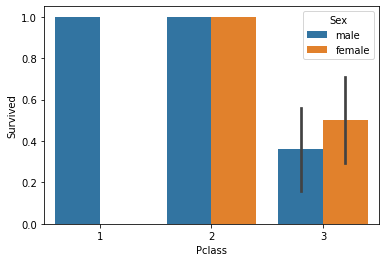

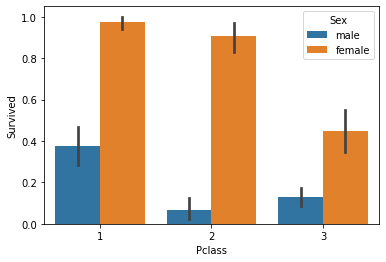

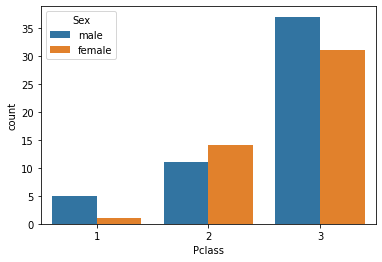

'\n--> More females are survived and survival ratio of less then 14 is also high. So, that we can say that"Women and children \nfirst" also apply to the third class.\n--> The number of passanges is much higher in third class then first and second. It can take more time to reach to lift boats\nis high for third class passangers. These circumstances leads to the lower survival ratio.\n\n'

In [6]:
#Task 5.1
plt.figure(7)
#Your code
sns.barplot(x='Pclass', y= 'Survived', hue='Sex', data= df_titanic[df_titanic['Age'] < 14])
plt.show()

"""
--> For age less then 14, there are no female survived in first class, number of male and female survived are same in second class and
there are more female survived then man in third class.
"""



#Task 5.2
plt.figure(8)
#Your code
sns.barplot(x='Pclass', y= 'Survived', hue='Sex', data= df_titanic[df_titanic['Age'] >= 14])
plt.show()


"""
--> For age higher then 14 the scenario is inversed. There are more female survived in first class and less in third class.
"""



#Task 5.3
plt.figure(9)
#Your code
sns.countplot(x='Pclass', hue='Sex', data= df_titanic[df_titanic['Age'] < 14])
plt.show()



#Task 5.4
"""
--> More females are survived and survival ratio of less then 14 is also high. So, that we can say that"Women and children 
first" also apply to the third class.
--> The number of passanges is much higher in third class then first and second. It can take more time to reach to lift boats
is high for third class passangers. These circumstances leads to the lower survival ratio.

"""

<div class="alert alert-block alert-warning">

## Task 6


Most of the lifeboats where on Deck A. Lets investigate the implication for the survival of the passengers.
As we have seen, most of the cabin data is missing. Nonetheless, lets see if we can still extract some information.

6.1 What percentage of Cabin values missing in each Pclass? Use isnull() and value_counts() to find it out!

It seems the first class only has about 20% missing values! Lets continue our investigation!

* 6.2 Drop all rows with missing Cabin values. Save the result in the variable <i>df_titanic_nona</i>
* 6.3 Extract the first letter of each entry in the Cabin column. Save the result in a new column called "Level" in the <i>df_titanic_nona</i> data frame
* 6.4 Plot Fare by Level using a <strong>barplot()</strong> of the first class Passengers. What is the level with the lowest average fare(ignoring level T)? Does that make sense to you given the location?

6.5 What is the survival rate by level? (lifeboards were located on deck A (prominade deck)) Anything unusual about deck A?

6.6 What is the ratio of male to female passengers on each deck? Use a barplot to illustrate. Does it explain the survival rate for deck A?



</div>

First Class Missing Values:  20.743034055727556
Second Class Missing Values:  91.69675090252707
Third Class Missing Values:  97.74330042313117


<Figure size 432x288 with 0 Axes>

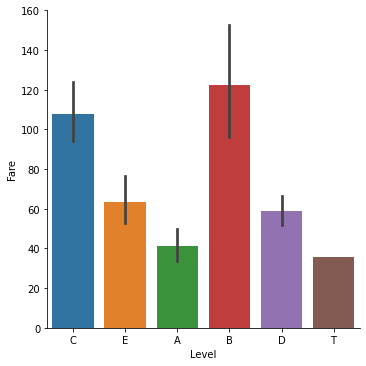

<Figure size 432x288 with 0 Axes>

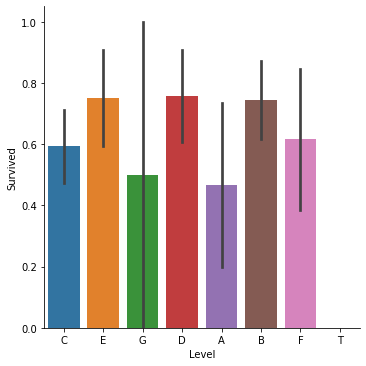

<Figure size 432x288 with 0 Axes>

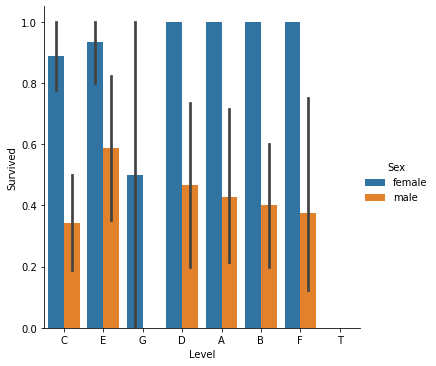

"\n-->On deck A there are too many female then male that's why survival ration is low.\n"

In [7]:
#Task 6.1
#Your code
print("First Class Missing Values: ", df_titanic[df_titanic['Pclass'] == 1]['Cabin'].isnull().value_counts()[1] * 100 / (df_titanic[df_titanic['Pclass'] == 1]['Cabin'].isnull().value_counts()[0] + df_titanic[df_titanic['Pclass'] == 1]['Cabin'].isnull().value_counts()[1]))
print("Second Class Missing Values: ", df_titanic[df_titanic['Pclass'] == 2]['Cabin'].isnull().value_counts()[1] * 100 / (df_titanic[df_titanic['Pclass'] == 2]['Cabin'].isnull().value_counts()[0] + df_titanic[df_titanic['Pclass'] == 2]['Cabin'].isnull().value_counts()[1]))
print("Third Class Missing Values: ", df_titanic[df_titanic['Pclass'] == 3]['Cabin'].isnull().value_counts()[1] * 100 / (df_titanic[df_titanic['Pclass'] == 3]['Cabin'].isnull().value_counts()[0] + df_titanic[df_titanic['Pclass'] == 3]['Cabin'].isnull().value_counts()[1]))


#Task 6.2
#Your code
df_titanic_nona = df_titanic.dropna(subset=['Cabin'], how='all')


#Task 6.3
#Your code
df_titanic_nona['Level'] = df_titanic_nona['Cabin'].astype(str).str[0]


#Task 6.4
plt.figure(10)
#Your code
sns.catplot(x='Level', y= 'Fare', kind='bar', data= df_titanic_nona[df_titanic_nona['Pclass'] ==1])
plt.show()

"""
--> Level A is with the lowest average fare. Np, there are not any pattern to recognize.
"""

#Task 6.5 
plt.figure(11)
#Your code
sns.catplot(x='Level', y= 'Survived', kind='bar', data= df_titanic_nona)
plt.show()

"""
--> Survival rate with level A is lowest. it is unusal since lifebots are located at deck A.
"""


#Task 6.6
plt.figure(12)
#Your code
sns.catplot(x='Level', y= 'Survived', hue='Sex', kind='bar', data= df_titanic_nona)
plt.show()


"""
-->On deck A there are too many female then male that's why survival ration is low.
"""




<div class="alert alert-block alert-warning">

## Task 7


Now it is time to show our resourcefullness! We don't know the fate for some of the passengers on deck A! Sometimes we need to consult other sources of data, outside what we are presented with, to fill in the gaps!

7.1 Save passenger data of level A into the variable <i>df_deckA</i>. Only save the columns "Cabin", "Name", "Survived" and "Age". Sort by "Cabin" and print the dataframe (.head())

7.2 Use online recources, search for the names of the passengers with missing values in the survived column and find out if their survived! provide next to each name if they survived (1) or died (0).


</div>

In [8]:

#Task 7.1
#Your code
df_deckA = df_titanic_nona[df_titanic_nona['Level'] == 'A'][['Cabin', 'Name', 'Survived', 'Age']].sort_values(by=['Cabin'])
df_deckA.head()


#7.2
#Rosenbaum, Miss. Edith Louise        : 1
#Dulles, Mr. William Crothers         : 0
#Brady, Mr. John Bertram              : 0
#Evans, Miss. Edith Corse             : 0
#Dodge, Dr. Washington                : 1
#Dodge, Mrs. Washington(Ruth Vidaver) : 1
#Chevre, Mr. Paul Romaine             : 1

,Cabin,Name,Survived,Age
583,A10,"Ross, Mr. John Hugo",0.0,36.0
1099,A11,"Rosenbaum, Miss. Edith Louise",NaN,33.0
475,A14,"Clifford, Mr. George Quincy",0.0,NaN
556,A16,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",1.0,48.0
1222,A18,"Dulles, Mr. William Crothers",NaN,39.0
